In [1]:
import numpy as np
from scipy.integrate import solve_bvp

# Example
https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_bvp.html 


In [2]:
def fun(x, y):
    return np.vstack((y[1], -np.exp(y[0])))

In [3]:
def bc(ya, yb):
    return np.array([ya[0], yb[0]])

In [4]:
x = np.linspace(0, 1, 100)
guess_a = np.zeros((2, x.size))
y_b = np.zeros((2, x.size))
y_b[0] = 3
y_a,  y_b

NameError: name 'y_a' is not defined

In [5]:
res_a = solve_bvp(fun, bc, x, guess_a, verbose=2, max_nodes=1e5)
# res_b = solve_bvp(fun, bc, x, y_b, verbose=2)

   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          1.16e-06       0.00e+00          100             0       
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 1.16e-06 
Maximum boundary residual: 0.00e+00


In [14]:
res_a

       message: The algorithm converged to the desired accuracy.
       success: True
        status: 0
             x: [ 0.000e+00  2.500e-01  5.000e-01  7.500e-01  1.000e+00]
           sol: <scipy.interpolate._interpolate.PPoly object at 0x7e4e1e38a1c0>
             p: None
             y: [[ 0.000e+00  1.048e-01  1.405e-01  1.048e-01  0.000e+00]
                 [ 5.493e-01  2.843e-01 -6.702e-18 -2.843e-01 -5.493e-01]]
            yp: [[ 5.493e-01  2.843e-01 -6.702e-18 -2.843e-01 -5.493e-01]
                 [-1.000e+00 -1.110e+00 -1.151e+00 -1.110e+00 -1.000e+00]]
 rms_residuals: [ 9.865e-05  1.054e-04  1.054e-04  9.865e-05]
         niter: 1

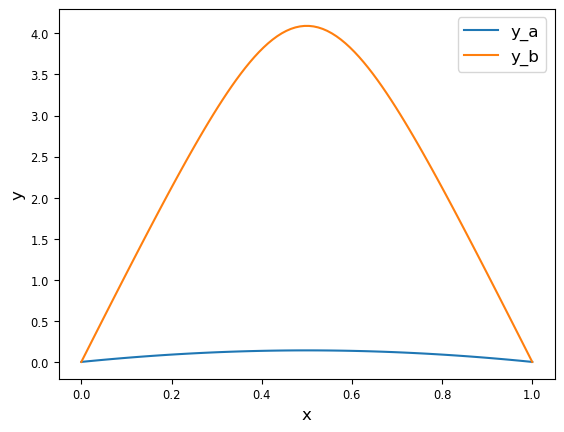

In [11]:
import matplotlib.pyplot as plt
x_plot = np.linspace(0, 1, 100)
y_plot_a = res_a.sol(x_plot)[0]
y_plot_b = res_b.sol(x_plot)[0]
plt.plot(x_plot, y_plot_a, label='y_a')
plt.plot(x_plot, y_plot_b, label='y_b')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# trying with my example

In [6]:
import numpy as np
from scipy.integrate import solve_bvp


def shape_integrator(x, y, params):
    # Only unknown parameters
    omega = params[0]

    k = 1        # multiples of k0 = 40 pN nm
    sigma = 1    # multiples of sigma0 = 0.05
    p = 0.0

    # Unpack y
    R = y[0]
    Z = y[1]
    psi = y[2]
    u = y[3]  # psidot
    v = y[4]  # psidotdot

    x1 = omega * np.cos(psi)  # R
    x2 = -omega * np.sin(psi)  # Z
    x3 = omega * u  # psi
    x4 = omega * v  # u (psidot)

    # Additional calculations for v
    v1 = (k * sigma * np.sin(psi)) / R
    v2 = -k * p
    v3 = k * sigma * u
    v4 = (3 * u**2 * np.sin(psi)) / (2 * R)
    v5 = (3 * u * np.cos(psi)**2) / (2 * R**2)
    v6 = -(2 * v * np.cos(psi)) / R
    v7 = -np.sin(psi) / (2 * R**3)
    v8 = -np.sin(psi) * np.cos(psi)**2 / (2 * R**3)
    v9 = -u / (2 * R**2)
    v10 = -0.5 * u**3

    x5 = omega * (v1 + v2 + v3 + v4 + v5 + v6 + v7 + v8 + v9 + v10)

    return np.vstack((x1, x2, x3, x4, x5))

In [11]:
def bc(ya, yb, p):
    omega = p[0]

    Rring = 20   # multiples of R0 = 20 nm
    k = 1        # multiples of k0 = 40 pN nm
    f = 0.8        # multiples of f0 = 12.6 pN
    sigma = 1    # multiples of sigma0 = 0.05
    p = 0.0

    psiguess = np.asin(2*f/(sigma*Rring))
    u0 = - omega*np.sin(psiguess)/Rring  # psidot

    # this is the correct adimensionalized version
    v0 = omega ** 2 * (-((f * (1 / np.cos(psiguess))) / Rring) - k * np.pi * p * Rring * (1 / np.cos(psiguess)) + (np.cos(psiguess) * np.sin(psiguess)) / (
        2 * Rring**22) + 0.5 * k * sigma * np.tan(psiguess) + np.tan(psiguess) / (2 * Rring**2) - (np.cos(psiguess) * u0) / Rring - 0.5 * np.tan(psiguess) * u0 ** 2)

    # R,Z,psi,u,v
    resid_a_1 = ya[0] - 0.0001  # R

    resid_b_1 = yb[0] - Rring  # Rring
    resid_b_2 = yb[1] - 0.001    # Z = 0
    resid_b_psi = yb[2] - psiguess - 0.1    # Z = 0
    resid_b_3 = yb[3] - u0
    resid_b_4 = yb[4] - v0

    return np.array([resid_a_1, resid_b_1, resid_b_2, resid_b_3, resid_b_4, resid_b_psi])

In [23]:
x_mesh = np.linspace(0, 1, 100)
y_guess = np.ones((5, x_mesh.shape[0])) *  0.01

In [24]:
Rring = 20   # multiples of R0 = 20 nm
k = 1        # multiples of k0 = 40 pN nm
f = 0.8        # multiples of f0 = 12.6 pN
sigma = 1    # multiples of sigma0 = 0.05
p = 0.0


# some BCs
omega_guess = 1.0
psiguess = np.asin(2*f/(sigma*Rring))


u0 = - omega_guess*np.sin(psiguess)/Rring  # psidot

# this is the correct adimensionalized version
v0 = omega_guess ** 2 * (-((f * (1 / np.cos(psiguess))) / Rring) - k * np.pi * p * Rring * (1 / np.cos(psiguess)) + (np.cos(psiguess) * np.sin(psiguess)) / (
    2 * Rring**22) + 0.5 * k * sigma * np.tan(psiguess) + np.tan(psiguess) / (2 * Rring**2) - (np.cos(psiguess) * u0) / Rring - 0.5 * np.tan(psiguess) * u0 ** 2)

# print(psiguess, u0, v0)

In [25]:
res_flow = solve_bvp(shape_integrator, bc,
                     x_mesh, y_guess, p=[omega_guess], verbose=2, max_nodes=100000)

   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          3.39e+10       3.74e+02          100            198      
Singular Jacobian encountered when solving the collocation system on iteration 2. 
Maximum relative residual: 1.59e+11 
Maximum boundary residual: 3.74e+02
